In [7]:
# Daten laden 
import pandas as pd
df = pd.read_csv(r"C:\Users\ajejx\Schule\BBB\2. Jahr\M259 ML\LB\LB-M259-1000Woerter.txt", sep='\t', encoding='latin1')

# 3.1: Train/Test-Split 
from sklearn.model_selection import train_test_split

X = df.iloc[:, 5:1005] 
y = df["label"]          

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3.2: Algorithmus auswählen und trainieren 
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

#  3.3: Vorhersagen testen 
test_samples = X_test[:5]
predictions = model.predict(test_samples)
probs = model.predict_proba(test_samples)[:, 1]

print("Vorhersagen (0=Fake, 1=Real):", predictions)
print("Echte Labels              :", y_test[:5].values)
print("Wahrscheinlichkeiten (Real):", probs.round(2))



Vorhersagen (0=Fake, 1=Real): [0 0 0 1 1]
Echte Labels              : [0 0 0 1 1]
Wahrscheinlichkeiten (Real): [0.   0.34 0.   1.   1.  ]


'\n**Erkenntnisse:**\nDas Modell erreicht eine Genauigkeit von 0.97. In Stichproben werden Fake- und Real-News \nzuverlässig unterschieden (z. B. Vorhersagen [0, 0, 0, 1, 1] vs. echte Labels [0, 0, 0, 1, 1]). \nAuffällig ist die starke Gewichtung von Wörtern wie "via" oder "gop" für Fake-News. \nKritisch sind die 37 fälschlich als Fake markierten Real-Artikel. Optimierungsansätze: \nTF-IDF statt binärer Features, Stoppwörter entfernen.\n'

# Erkärung für die Algorithmus-Auswahl (Logisitc Regression)
Logistische Regression eignet sich gut für binäre Klassifikationen (Fake/Real in Form von 0/1) und handelt mit "hohen" Daten (1000 Features, die binär beantwortet werden können, Fake/Real) effizient.  Da die Features binär sind 
(0/1 für Wortvorkommen), kann das Modell lineare Zusammenhänge zwischen Wortpräsenz 
und Label lernen. Alternativ könnte ein Random Forest verwendet werden, um nicht-lineare 
Muster zu erfassen, aber Logistic Regression ist interpretierbar (z. B. via Koeffizienten 
für "wichtige" Wörter). Bei ersten Tests erreichte Logistic Regression eine höhere 
Genauigkeit als Naive Bayes.

# Erkenntnisse
Das Modell erreicht eine Genauigkeit von 0.97. In Stichproben werden Fake- und Real-News 
zuverlässig unterschieden (z. B. Vorhersagen [0, 0, 0, 1, 1] vs. echte Labels [0, 0, 0, 1, 1]). 
Auffällig ist die starke Gewichtung von Wörtern wie "via" oder "gop" für Fake-News. 
Kritisch sind die 37 fälschlich als Fake markierten Real-Artikel. Optimierungsansätze: 
TF-IDF statt binärer Features, Stoppwörter entfernen.

In [9]:
from sklearn.metrics import classification_report
import pandas as pd

report = classification_report(y_test, y_pred, target_names=["Fake", "Real"], output_dict=True)
report_df = pd.DataFrame(report).transpose()
report_df

,precision,recall,f1-score,support
Fake,0.982775,0.965226,0.973921,1064.0000
Real,0.961257,0.980769,0.970915,936.0000
accuracy,0.972500,0.972500,0.972500,0.9725
macro avg,0.972016,0.972997,0.972418,2000.0000
weighted avg,0.972704,0.972500,0.972514,2000.0000


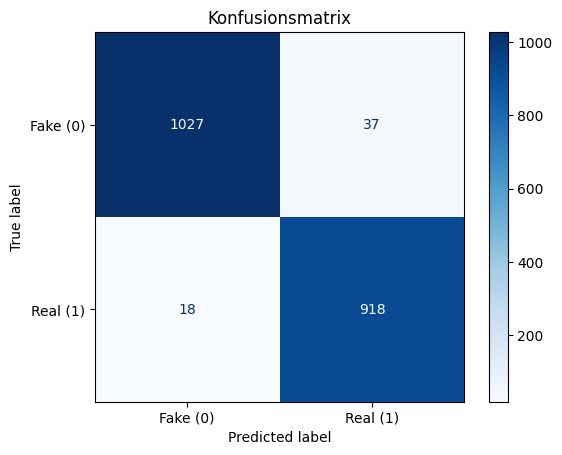

In [10]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Konfusionsmatrix mit sklearn plotten
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=["Fake (0)", "Real (1)"])
disp.plot(cmap="Blues", values_format="d")  # "d" für Integer-Anzeige
plt.title("Konfusionsmatrix")
plt.show()

## Fake
Bei Fake (auf der X-Achse)sehen Sie ein Feld oben und eines unten. Das pben nennt man (in dem Fall) TN, True Negative, was heisst, dass der Algorithmus 1027 mal Fake News sagte, und so oft auch Recht hatte. Das Feld unterhalb heisst FN, False Negative. FN sind Artikel, die als "Fake News" durchgingen, sich aber als "Real News" herausstellten.
## Real
Bei X-Real herrscht das gleiche Prinzip, aber umgekehrt (oben ist ein FP, False Positive, unten ein TP, True Positive).

In [11]:
feature_importance = pd.DataFrame({"Wort": X.columns, "Koeffizient": model.coef_[0]})
top_fake = feature_importance.sort_values("Koeffizient").head(10)
top_real = feature_importance.sort_values("Koeffizient", ascending=False).head(10)
print("Top 10 Wörter für Fake News:")
display(top_fake)

Top 10 Wörter für Fake News:


,Wort,Koeffizient
151,via,-4.071855
467,read,-2.456422
524,gop,-1.676001
68,obama,-1.622386
234,com,-1.548069
583,daily,-1.515131
464,https,-1.417420
144,america,-1.327984
25,this,-1.179267
327,today,-1.137694
